
<hr style="border:2px solid #2196F3;">

## 🧑‍💻 Lecture 01 - Simple Random Sampling vs Convenience Sampling vs Stratified Sampling

<hr style="border:2px solid #2196F3;">

### 🔎Dataset: spotify_songs.csv

This dataset consists of 600+ songs that were in the top songs of the year from 2010 to 2019 (as measured by Billboard). You can explore interesting song data pulled from Spotify such as the beats per minute, amount of spoken words, loudness, and energy of every song. More description of the dataset can be found [here](https://www.kaggle.com/datasets/leonardopena/top-spotify-songs-from-20102019-by-year).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>⚠️ Upload the dataset spotify_songs.csv to the current file folder before running the next cell!!! </b>

In [ ]:
spotify_songs = pd.read_csv('spotify_songs.csv') # revise the folder path when you run the code

In [ ]:
spotify_songs.head()

,index,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,2,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,3,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,4,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,5,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78


In [ ]:
display(spotify_songs)

,index,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,2,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,3,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,4,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,5,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,599,Find U Again (feat. Camila Cabello),Mark Ronson,dance pop,2019,104,66,61,-7,20,16,176,1,3,75
599,600,Cross Me (feat. Chance the Rapper & PnB Rock),Ed Sheeran,pop,2019,95,79,75,-6,7,61,206,21,12,75
600,601,"No Brainer (feat. Justin Bieber, Chance the Ra...",DJ Khaled,dance pop,2019,136,76,53,-5,9,65,260,7,34,70
601,602,Nothing Breaks Like a Heart (feat. Miley Cyrus),Mark Ronson,dance pop,2019,114,79,60,-6,42,24,217,1,7,69


In [ ]:
# Calculate the mean duration from the population
mean_pop = spotify_songs['dur'].mean()

# Print the means
print(mean_pop)

224.67495854063017


## <b>🎯Simple Random Sampling </b>



In [ ]:
# Sample 30 random rows from the 'population' spotify_songs
spotify_sample = spotify_songs.sample(n=30, random_state = 10000)

# or alternatively, you can specify the fraction of sample to select say 10%
# spotify_sample = spotify_songs.sample(frac=0.1, random_state = 10000)

# Calculate the mean duration from the sample
mean_samp = spotify_sample['dur'].mean()

# Print the means
print(mean_samp)

224.13333333333333


## <b>🎯Convenience Sampling </b>

In [ ]:
# Convenience sampling
spotify_first30 = spotify_songs.head(30)
print(np.mean(spotify_first30['dur']))

231.13333333333333


In [ ]:
print(max(spotify_songs['dur']), min(spotify_songs['dur']))

424 134


<b> 💡 Sample mean from Simple Random Sampling is more close to the population mean.</b>

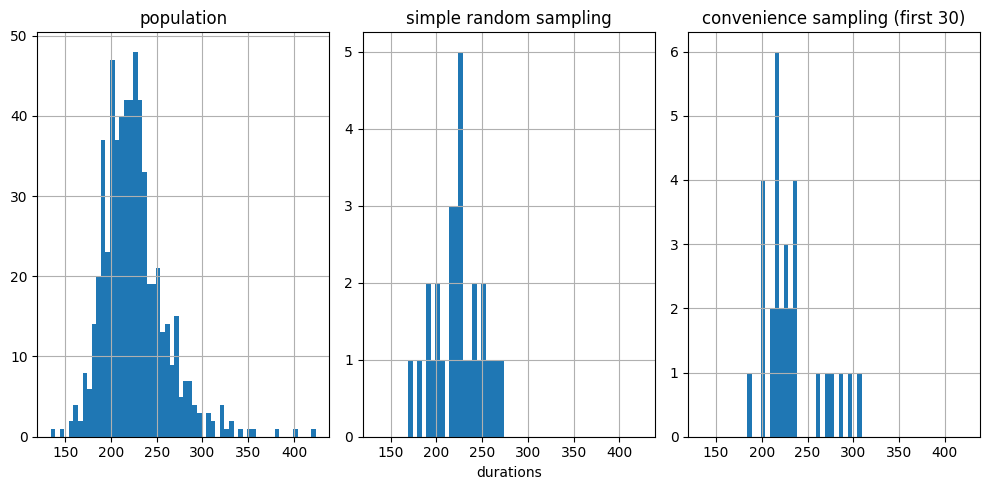

In [ ]:
# fig, axis = plt.subplots(1, 3, figsize=(10, 5))

plt.subplots(figsize=(10, 5))
plt.clf()

plt.subplot(1, 3, 1)
spotify_songs['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('population')

plt.subplot(1, 3, 2)
spotify_sample['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('simple random sampling')

plt.xlabel('durations')

plt.subplot(1, 3, 3)
spotify_first30['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('convenience sampling (first 30)')

plt.tight_layout()
plt.show()

<b> ❓How about other variable like 'acous'? Which sampling method is more representative of population? </b>

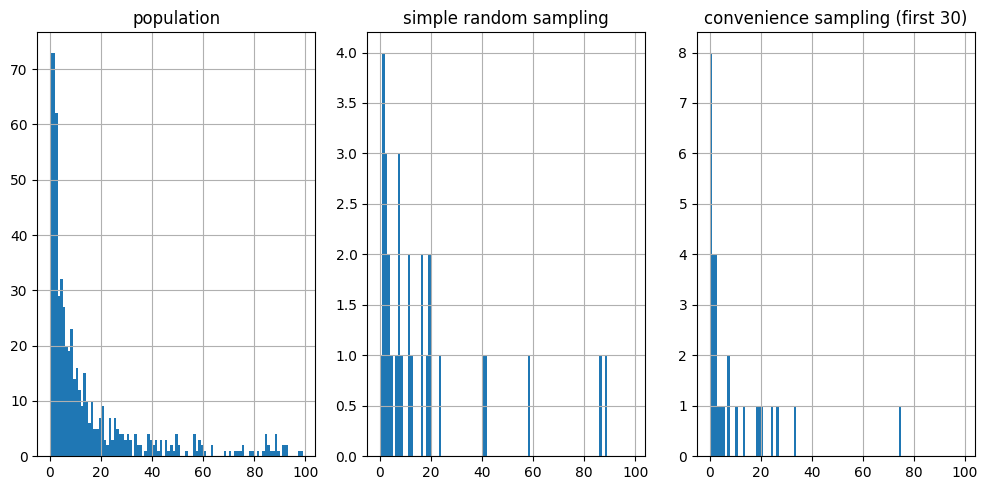

In [ ]:
plt.subplots(figsize=(10, 5))
plt.clf()

plt.subplot(1, 3, 1)
spotify_songs['acous'].hist(bins=np.arange(0, 100, 1))
plt.title('population')

plt.subplot(1, 3, 2)
spotify_sample['acous'].hist(bins=np.arange(0, 100, 1))
plt.title('simple random sampling')

plt.subplot(1, 3, 3)
spotify_first30['acous'].hist(bins=np.arange(0, 100, 1))
plt.title('convenience sampling (first 30)')

plt.tight_layout()
plt.show()

## <b>🎯 Stratified Sampling </b>

In [ ]:
strata_by_year = spotify_songs.groupby('year').sample(n=3, random_state = 10000)
strata_by_year['year'].value_counts()

,count
year,
2010,3
2011,3
2012,3
2013,3
2014,3
2015,3
2016,3
2017,3
2018,3


In [ ]:
print(spotify_songs['dur'].mean()) # pop mean
print(strata_by_year['dur'].mean(), max(strata_by_year['dur']), min(strata_by_year['dur'])) # sample mean

224.67495854063017
221.43333333333334 379 170


Text(0.5, 1.0, 'stratified sample')

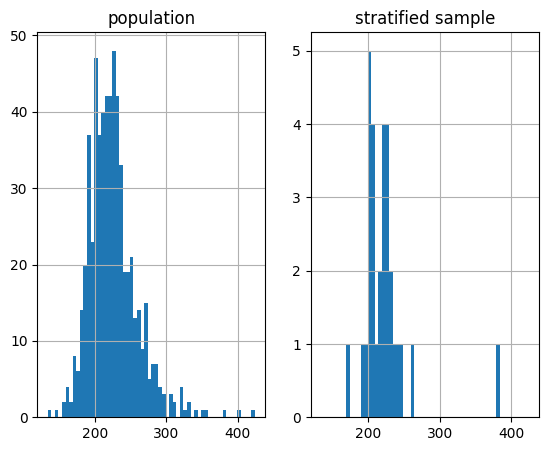

In [ ]:
plt.subplots(figsize=(10, 5))
plt.clf()

plt.subplot(1, 3, 1)
spotify_songs['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('population')

plt.subplot(1, 3, 2)
strata_by_year['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('stratified sample')

<b> 💡In the naive stratified sampling, the sample size selected from each stratum is equal. However, in general, it can be different weightages. For example, in this dataset, different years have different number of songs. </b>

In [ ]:
spotify_songs['year'].value_counts()

,count
year,
2015,95
2016,80
2013,71
2017,65
2018,64
2014,58
2011,53
2010,51
2012,35


In [ ]:
spotify_songs.groupby('year')['dur'].mean() # the mean durations in diff years are not the same

,dur
year,
2010,229.803922
2011,242.566038
2012,224.400000
2013,234.492958
2014,224.155172
2015,223.368421
2016,220.225000
2017,222.169231
2018,217.187500


In [ ]:
weights_by_year = pd.DataFrame(spotify_songs['year'].value_counts(normalize=True))
weights_by_year.reset_index(inplace=True)
weights_by_year.rename(columns={'proportion':'weights'}, inplace=True)

display(weights_by_year)

,year,weights
0,2015,0.157546
1,2016,0.132670
2,2013,0.117745
3,2017,0.107794
4,2018,0.106136
5,2014,0.096186
6,2011,0.087894
7,2010,0.084577
8,2012,0.058043
9,2019,0.051410


In [ ]:
copy_spotify_songs = spotify_songs.copy() # here I create a copy of df so that the original df is not manipulated
display(copy_spotify_songs.head())

print('')
print('-'*120)
print('')

copy_spotify_songs = copy_spotify_songs.merge(weights_by_year, left_on='year', right_on='year') # or on='year' when it is the same column name for matching
display(copy_spotify_songs.head())

,index,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,2,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,3,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,4,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,5,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78



------------------------------------------------------------------------------------------------------------------------



,index,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,weights
0,1,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83,0.084577
1,2,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82,0.084577
2,3,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80,0.084577
3,4,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79,0.084577
4,5,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78,0.084577


In [ ]:
weighted_spotify_sample = copy_spotify_songs.sample(frac=0.1, weights=copy_spotify_songs['weights'])

weighted_spotify_sample['year'].value_counts(normalize=True)

,proportion
year,
2013,0.166667
2015,0.150000
2018,0.133333
2017,0.133333
2016,0.100000
2014,0.083333
2010,0.083333
2011,0.066667
2019,0.050000


✅ It does not exactly match the weightages as shown in the original datasets for 2 reasons: 1. The weightage matrix is just a probability for sampling. When it comes to the realizations, it may not have exactly the same percentage for each year. 2. As it is a probability, when you slowly increase the sample size, the sample size distribution over different years will ideally get closer and closer to the desired percentage.

In [ ]:
print(spotify_songs['dur'].mean())
print(weighted_spotify_sample['dur'].mean(), max(weighted_spotify_sample['dur']), min(weighted_spotify_sample['dur']))

224.67495854063017
226.95 353 181


Text(0.5, 1.0, 'weighted sample')

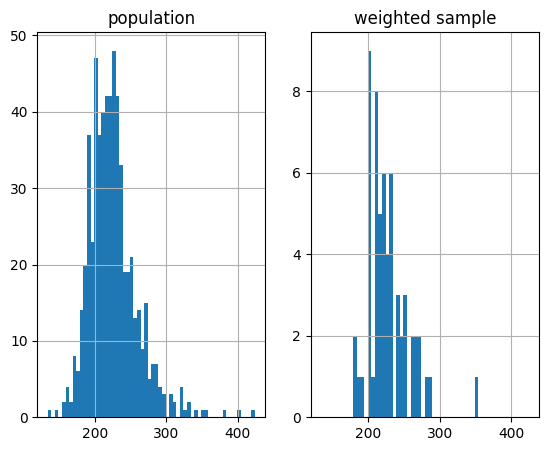

In [ ]:
plt.subplots(figsize=(10, 5))
plt.clf()

plt.subplot(1, 3, 1)
spotify_songs['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('population')

plt.subplot(1, 3, 2)
weighted_spotify_sample['dur'].hist(bins=np.arange(134, 425, 5))
plt.title('weighted sample')

## 👏👏👏👏Congratulation🎉🎉🎉🎉